In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
import string 
import nltk
pd.set_option('display.max_colwidth', 100)
messages = pd.read_csv("C:\\Users\\ASUS\\Downloads\\spam.csv", encoding='latin-1')
messages.head()


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


In [8]:
messages.describe()
messages.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [11]:
messages.columns = ['label', 'message']
print("Number of nulls in label column: ", messages['label'].isnull().sum())
print("Number of nulls in message column: ", messages['message'].isnull().sum())
print("Number of unique labels: ", messages['label'].nunique())
messages.head()

Number of nulls in label column:  0
Number of nulls in message column:  0
Number of unique labels:  2


,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


In [10]:
messages['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

<Axes: xlabel='label'>

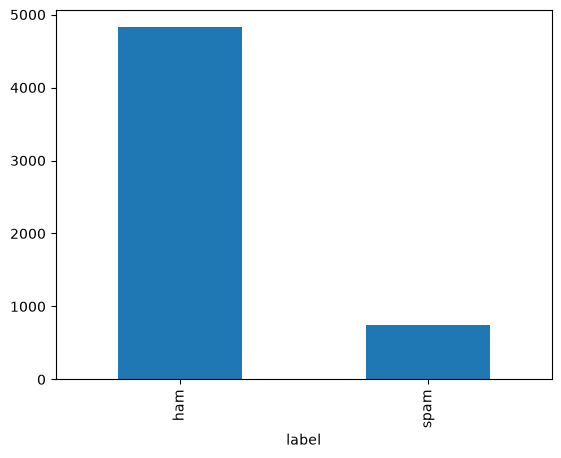

In [12]:
messages['label'].value_counts().plot(kind='bar')


In [13]:
# clean dataset
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string
import re
from sklearn.feature_extraction.text import CountVectorizer


In [14]:
def clean_text(text):
    text="".join([char for char in text if char not in string.punctuation])
    tokens=re.split('\W+',text)
    text=[word for word in tokens if word not in stopwords.words('english')]
    return text

<>:3: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<>:3: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22720\798213193.py:3: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
  tokens=re.split('\W+',text)


In [21]:
import nltk 
nltk.download('stopwords')
from nltk .corpus import stopwords
clean_text(" i love programming")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


['', 'love', 'programming']

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Note the capital T and V in the class name
tfidf_vectorizer = TfidfVectorizer(analyzer=clean_text)
x_tfidf = tfidf_vectorizer.fit_transform(messages['message'])
print(x_tfidf.shape)
print(tfidf_vectorizer.get_feature_names_out())


(5572, 11582)
['' '0' '008704050406' ... 'Ã¼' 'Ã¼ll' 'â']


In [27]:
x_fetaures= pd.DataFrame(x_tfidf.toarray())
x_fetaures.head(30)

,0,1,2,3,4,5,6,7,8,9,...,11572,11573,11574,11575,11576,11577,11578,11579,11580,11581
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.140395,0.0,0.000000,0.0,0.0
6,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
7,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
8,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.135411,0.0,0.000000,0.0,0.0
9,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0


In [26]:
print("Random forest for classification")

Random forest for classification


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x_fetaures, messages['label'], test_size=0.2, random_state=42)
y_train

1978    spam
3989     ham
3935     ham
4078     ham
4086    spam
        ... 
3772     ham
5191     ham
5226     ham
5390     ham
860      ham
Name: label, Length: 4457, dtype: str

In [31]:
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf_model=rf.fit(x_train, y_train)
y_pred=rf_model.predict(x_test)

In [32]:
precision = precision_score(y_test, y_pred, pos_label='spam')
recall = recall_score(y_test, y_pred, pos_label='spam')
print('precision:{}/recall:{}'.format(round(precision, 3), round(recall, 3)))

precision:1.0/recall:0.846


In [34]:
print("TESTING")

TESTING


In [36]:
text=["ArithmeticError is the base class for those built-in exceptions that are raised for various arithmetic errors. It is a subclass of Exception. The ArithmeticError class is not meant to be directly inherited by user-defined classes. Instead, it serves as a base class for more specific arithmetic error classes, such as ZeroDivisionError, OverflowError, and FloatingPointError."]
test_tfidf = tfidf_vectorizer.transform(text)
x_features= pd.DataFrame(test_tfidf.toarray())
x_features.head()

,0,1,2,3,4,5,6,7,8,9,...,11572,11573,11574,11575,11576,11577,11578,11579,11580,11581
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
y_pred=rf_model.predict(test_tfidf)
y_pred

array(['ham'], dtype=object)